<a href="https://colab.research.google.com/github/princeiiitk/Preventing-Customer-Churn-with-Feature-Transformation/blob/main/Preventing_Customer_Churn_with_Feature_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [994]:
!git clone 'https://github.com/princeiiitk/Preventing-Customer-Churn-with-Feature-Transformation'

fatal: destination path 'Preventing-Customer-Churn-with-Feature-Transformation' already exists and is not an empty directory.


In [995]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [996]:
df=pd.read_csv('/content/Preventing-Customer-Churn-with-Feature-Transformation/Telco-Customer-Churn.csv')

In [997]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [998]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**No Missing value in datase**t

In [999]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Step 2: Data Cleaning and Initial Preparation

In [1000]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Problem with existing data set is `TotalCharge`s columns data type is `Object` it should be Float/int

In [1001]:
print('shape before cleaning ',df.shape)

shape before cleaning  (7043, 21)


In [1002]:

# Convert Totalcharges to numeric, coercing error to Nan
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print('shape after converting totalcharges to numeric',df.shape)

shape after converting totalcharges to numeric (7043, 21)


In [1003]:
# find how many row have missing totalcharges
df['TotalCharges'].isnull().sum()

np.int64(11)

In [1004]:
# impute the missing value with the median
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())
print('shape after converting totalcharges to numeric',df.shape)

shape after converting totalcharges to numeric (7043, 21)


In [1005]:
# convert target variable 'churn' to binary
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [1006]:
# Drop row with missing churn value
df.dropna(subset='Churn',inplace=True)

In [1007]:
df.shape

(7043, 21)

In [1008]:
# pd.set_option('display.max_columns',None)
# display(df.head(3))
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [1009]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


# Step 3: Model 1 - Baseline Performance (Without Feature Engineering)

In [1010]:
X_without_Feature_eng=df.drop(columns=['customerID','Churn'])
y_without_Feature_eng=df['Churn']

In [1011]:
# identify Categorical and numerical features
numerical_features1=X_without_Feature_eng.select_dtypes(include=np.number)
categorical_features1=X_without_Feature_eng.select_dtypes(exclude=np.number)

In [1012]:
# creating the preprocessing pipeline

preprocessing_1=ColumnTransformer([
    ('num',StandardScaler(),numerical_features1.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features1.columns)
])

In [1013]:
X_without_Feature_eng_train,X_without_Feature_eng_test,y_without_Feature_eng_train,y_without_Feature_eng_test=train_test_split(X_without_Feature_eng,y_without_Feature_eng,test_size=0.2,random_state=42,stratify=y_without_Feature_eng)

In [1014]:
# creating the full pipeline with classifer
model1=Pipeline(
    steps=[
        ('preprocessing',preprocessing_1),
        ('classifier',LogisticRegression(random_state=42,max_iter=1000))
    ]
)

In [1015]:
# Model training
model1.fit(X_without_Feature_eng_train,y_without_Feature_eng_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [1016]:
y_pred_without_feature_engineer=model1.predict(X_without_Feature_eng_test)


In [1017]:
accuracy_without_feature_engineer=accuracy_score(y_without_Feature_eng_test,y_pred_without_feature_engineer)
print('Accuracy without feature engineering',accuracy_without_feature_engineer)

Accuracy without feature engineering 0.8055358410220014


In [1018]:
from sklearn.metrics import classification_report

print("--- Baseline Model_1 Performance ---")

classification_report_without_feature_eng = classification_report(
    y_without_Feature_eng_test,
    y_pred_without_feature_engineer,
    output_dict=True
)

accuracy = classification_report_without_feature_eng['accuracy']

precision = classification_report_without_feature_eng['1']['precision']

recall = classification_report_without_feature_eng['1']['recall']

f1 = classification_report_without_feature_eng['1']['f1-score']

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

--- Baseline Model_1 Performance ---
Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1-score: 0.6040462427745664


## Step 4: The Core Task - Feature Engineering
Now, let's create a new, enriched DataFrame with more intelligent features.
## Step 5: Model 2 - Performance with Engineered Features

In [1019]:
df['tenure'].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [1020]:
df_eng=df.copy()


In [1021]:
# 1.Binning  'tenure'
bins=[0,12,24,36,48,60,72]
labels=['0-1 Year','1-2 Years','2-3 Years','3-4 Years','4-5 Years','5+ Years']
df_eng['tenure_group']=pd.cut(df_eng['tenure'],bins=bins,labels=labels,right=False)




In [1022]:
# 2. Simplify categorical feature

# col=df_eng.columns
# for i in col:
#   for j in df_eng[i].unique():
#      if j in ['No internet service', 'No phone service']:
#             df_eng[i] = df_eng[i].replace(j, 'No')

df_eng.replace(['No internet service', 'No phone service'], 'No', inplace=True)

In [1023]:
# 3 creating interaction/combination features
df_eng['num_add_service']=(df_eng[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']] =='Yes').sum(axis=1)

# 4. Create a feature for monthly charge to tenure ratio
df_eng['monthly_charge_ratio'] = df_eng['MonthlyCharges'] / (df_eng['tenure'] + 1) # +1 to avoid division by zero

In [1024]:
df_eng.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_service,monthly_charge_ratio
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,2-3 Years,2,1.627143
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,17.950000
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 Years,3,0.919565
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,23.566667
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,0-1 Year,3,11.072222
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,1-2 Years,2,3.873913
7,6713-OKOMC,Female,0,No,No,10,No,No,DSL,Yes,...,No,Month-to-month,No,Mailed check,29.75,301.90,0,0-1 Year,1,2.704545
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,2-3 Years,4,3.613793
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),56.15,3487.95,0,5+ Years,2,0.891270


In [1025]:
# Drop original tenure as we have a binned version now
df_eng.drop(columns=['tenure','customerID'],inplace=True)

# define feature (X) and target (y) for the engineer dataset
X_with_feature_eng = df_eng.drop('Churn', axis=1)
y_with_feature_eng = df_eng['Churn']

# Identify new feature type
numerical_features_eng2=X_with_feature_eng.select_dtypes(include=np.number)
categorical_features_eng2=X_with_feature_eng.select_dtypes(include=['object','category'])

# creating preprocessing pipeline
preprocessing_2 = ColumnTransformer([
    ('num',StandardScaler(),numerical_features_eng2.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features_eng2.columns)
])

# spliting
X_train_with_feature_eng, X_test_with_feature_eng, y_train_with_feature_eng, y_test_with_feature_eng = train_test_split(X_with_feature_eng, y_with_feature_eng, test_size=0.2, random_state=42, stratify=y_with_feature_eng)

In [1026]:
# Make pipeline
model2=Pipeline(
    steps=[(
        'preprocessing',preprocessing_2),
           ('classifier',LogisticRegression(random_state=42,max_iter=1000))]
)

In [1027]:
# Train and evaluate the enhanced model
model2.fit(X_train_with_feature_eng, y_train_with_feature_eng)
y_pred_eng =model2.predict(X_test_with_feature_eng)



In [1028]:


report_with_feature_eng = classification_report(
    y_test_with_feature_eng,
    y_pred_eng,
    output_dict=True
)

# extract metrics
accuracy = report_with_feature_eng['accuracy']

precision = report_with_feature_eng['1']['precision']

recall = report_with_feature_eng['1']['recall']

f1 = report_with_feature_eng['1']['f1-score']

# print metrics
print("--- Enhanced Model Performance ---")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

--- Enhanced Model Performance ---
Accuracy: 0.808374733853797
Precision: 0.6805555555555556
Recall: 0.5240641711229946
F1-score: 0.5921450151057401



# Step : Model 3 - Performance with Feature Engineering and best Features selection

In [1029]:
X_feature_selection=X_with_feature_eng
y_feature_selection=y_with_feature_eng


In [1030]:
# Identify new feature type
numerical_features_eng3=X_feature_selection.select_dtypes(include=np.number)
categorical_features_eng3=X_feature_selection.select_dtypes(include=['object','category'])

In [1031]:
preprocessing_3 = ColumnTransformer([
    ('num',StandardScaler(),numerical_features_eng3.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features_eng3.columns)
])

In [1032]:
X_train_with_feature_selection,X_test_with_feature_selection,y_train_with_feature_selection,y_test_with_feature_selection=train_test_split(X_feature_selection,y_feature_selection,test_size=0.2,random_state=42,stratify=y_feature_selection)
#

In [1033]:
# To get feature importance, let's quickly train a RandomForest model with the engineered data

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessing_3),
                               ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train_with_feature_selection, y_train_with_feature_selection)
# Extract feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

feature_importance_df

,Feature,Importance
4,num__monthly_charge_ratio,0.221482
2,num__TotalCharges,0.160325
1,num__MonthlyCharges,0.144410
10,cat__InternetService_Fiber optic,0.039871
3,num__num_add_service,0.036635
22,cat__PaymentMethod_Electronic check,0.034327
19,cat__Contract_Two year,0.029947
5,cat__gender_Male,0.025967
20,cat__PaperlessBilling_Yes,0.025961
12,cat__OnlineSecurity_Yes,0.022426


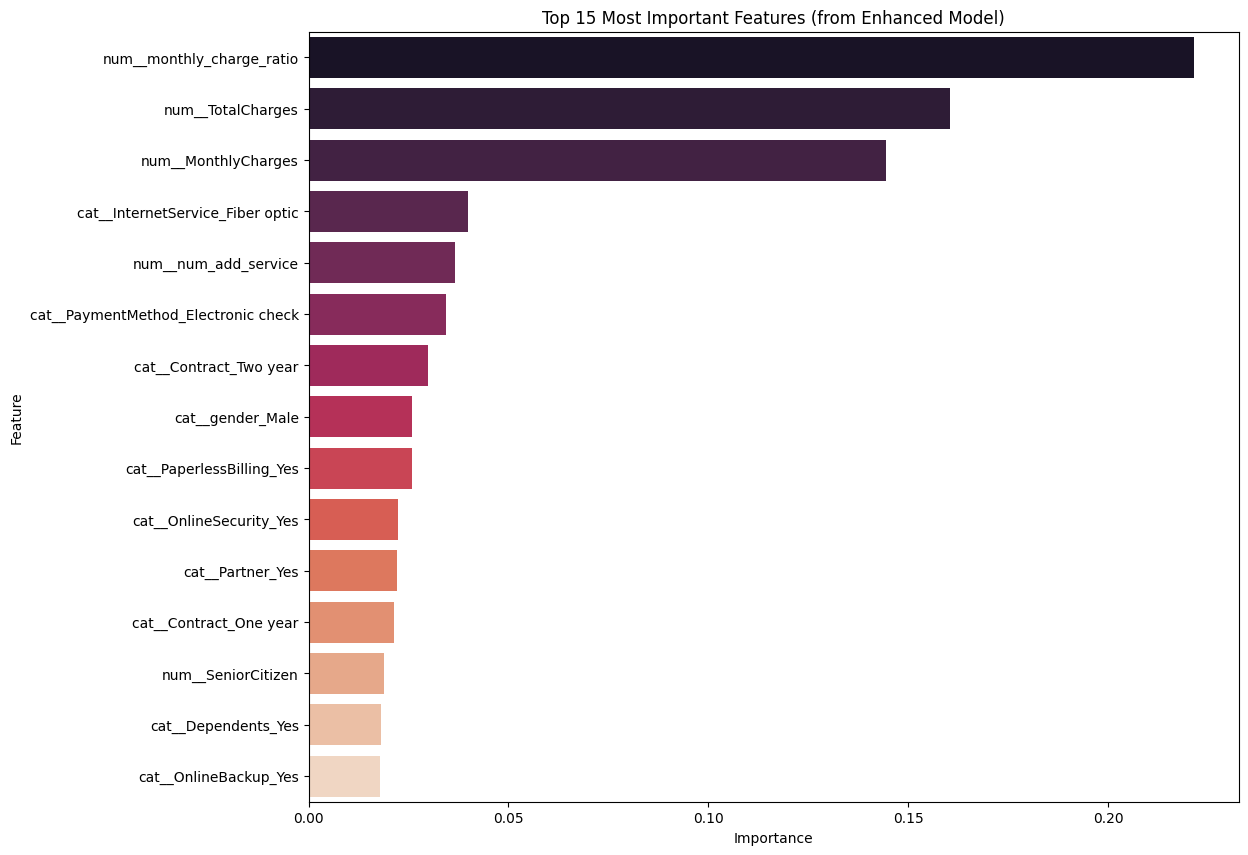

In [1034]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='rocket', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features (from Enhanced Model)')
plt.show()

In [1035]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier to use as the base estimator for feature selection
rf_selector = RandomForestClassifier(random_state=42)

# Instantiate SelectFromModel
# Using 'median' as the threshold means features with importance greater than the median importance will be selected.
selector = SelectFromModel(estimator=rf_selector, threshold='median', prefit=False)



model3=LogisticRegression()

pipeLine=Pipeline([
    ('preprocessing',preprocessing_3),
    ('selector',selector),
    ('classifier',model3)]

)


In [1036]:
pipeLine.fit(X_train_with_feature_selection,y_train_with_feature_selection)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'num_add_service',
       'monthly_charge_ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'tenure_group'],
      dtype='object'))])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 threshold='median')),
                ('classifier', LogisticRegression())])

In [1037]:
y_pred_with_feature_engineer_selection = pipeLine.predict(X_test_with_feature_selection)

In [1038]:
accuracy = accuracy_score(y_test_with_feature_selection, y_pred_with_feature_engineer_selection)

print("Accuracy:", accuracy)


Accuracy: 0.7998580553584103


In [1039]:
print(confusion_matrix(y_test_with_feature_selection,y_pred_with_feature_engineer_selection))

[[939  96]
 [186 188]]


In [1040]:
report_with_feature_selection_engineer = classification_report(
    y_test_with_feature_selection,
    y_pred_with_feature_engineer_selection,
    output_dict=True
)

accuracy = report_with_feature_selection_engineer['accuracy']

precision = report_with_feature_selection_engineer['1']['precision']

recall = report_with_feature_selection_engineer['1']['recall']

f1 = report_with_feature_selection_engineer['1']['f1-score']

print(accuracy)
print(precision)
print(recall)
print(f1)

0.7998580553584103
0.6619718309859155
0.5026737967914439
0.5714285714285714


#  perform hyperparameter tuning ti improve model performance or cheeck and accuracy On best Feature selection
X_train_with_feature_selection,  
X_test_with_feature_selection,  
y_train_with_feature_selection,  
y_test_with_feature_selection  


In [1041]:
X_train_with_feature_selection

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,num_add_service,monthly_charge_ratio
3738,Male,0,No,No,No,No,DSL,No,No,Yes,...,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,2-3 Years,3,1.366667
3151,Male,0,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,...,No,No,Month-to-month,No,Mailed check,75.10,1151.55,1-2 Years,1,4.693750
4860,Male,0,Yes,Yes,No,No,DSL,Yes,Yes,No,...,No,No,Two year,No,Mailed check,40.55,590.35,1-2 Years,3,2.896429
3867,Female,0,Yes,No,Yes,No,DSL,No,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,2-3 Years,4,2.722222
3810,Male,0,Yes,Yes,Yes,No,DSL,No,No,No,...,No,No,Month-to-month,No,Electronic check,44.55,44.55,0-1 Year,0,22.275000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,Female,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,...,Yes,Yes,Two year,No,Electronic check,109.25,7707.70,5+ Years,5,1.517361
6227,Male,0,No,No,Yes,No,DSL,No,No,No,...,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35,0-1 Year,0,15.350000
4673,Female,1,No,No,Yes,Yes,Fiber optic,Yes,Yes,No,...,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.20,2-3 Years,4,3.953846
2710,Female,0,Yes,No,Yes,No,No,No,No,No,...,No,No,One year,No,Credit card (automatic),20.40,482.80,2-3 Years,0,0.816000


In [1042]:
# Identify new feature type
numerical_features_eng4=X_feature_selection.select_dtypes(include=np.number)
categorical_features_eng4=X_feature_selection.select_dtypes(include=['object','category'])

In [1043]:
preprocessing_4=ColumnTransformer([
    ('num',StandardScaler(),numerical_features_eng4.columns),
    ('cat',OneHotEncoder(drop='first'),categorical_features_eng4.columns)
])


In [1044]:
model4=LogisticRegression(
    penalty='l2',
    C=0.2,
    solver='liblinear',
    max_iter=1000
)

pipeLine=Pipeline([
    ('preprocessing',preprocessing_4),
    ('selector',selector),
    ('classifier',model4)]

)

In [1045]:
pipeLine.fit(X_train_with_feature_selection,y_train_with_feature_selection)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'num_add_service',
       'monthly_charge_ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'tenure_group'],
      dtype='object'))])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 threshold='median')),
                ('classifier',
                 LogisticRegression(C=0.2, max_iter=1000, solver='liblinear'))])

In [1046]:
y_pred_with_Hyperparameter_tuning = pipeLine.predict(X_test_with_feature_selection)

In [1047]:
accuracy4=accuracy_score(y_test_with_feature_selection,y_pred_with_Hyperparameter_tuning)
print('Accuracy:',accuracy4)

Accuracy: 0.7970191625266146


In [1048]:
print(confusion_matrix(y_test_with_feature_selection,y_pred_with_Hyperparameter_tuning))

[[935 100]
 [186 188]]


In [1049]:
report_tune_lr = classification_report(
    y_test_with_feature_selection,
    y_pred_with_Hyperparameter_tuning,
    output_dict=True
)

accuracy = report_tune_lr['accuracy']
precision = report_tune_lr['1']['precision']
recall = report_tune_lr['1']['recall']
f1 = report_tune_lr['1']['f1-score']

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7970191625266146
Precision: 0.6527777777777778
Recall: 0.5026737967914439
F1-score: 0.56797583081571


# Applying Diffrent Algorithms

# Using SVM

In [1050]:
from sklearn.svm import SVC
model_svm=SVC(kernel='rbf')

pipeLine=Pipeline(
    steps=[('preprocessing',preprocessing_4),
           ('selector',selector),
           ('model_svm',model_svm)]
)

In [1051]:
pipeLine=pipeLine.fit(X_train_with_feature_selection,y_train_with_feature_selection)

In [1052]:
y_pred_svm=pipeLine.predict(X_test_with_feature_selection)

In [1053]:
accuracy_svm=accuracy_score(y_test_with_feature_selection,y_pred_svm)
print('Accuracy:',accuracy)

Accuracy: 0.7970191625266146


In [1054]:
report_svm = classification_report(
    y_test_with_feature_selection,
    y_pred_svm,
    output_dict=True
)

accuracy = report_svm['accuracy']
precision = report_svm['1']['precision']
recall = report_svm['1']['recall']
f1 = report_svm['1']['f1-score']

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7984386089425124
Precision: 0.6642335766423357
Recall: 0.48663101604278075
F1-score: 0.5617283950617284


# Using KNN

In [1055]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=3)


pipeLine=Pipeline(
    steps=[('preprocessing',preprocessing_4),
           ('selector',selector),
           ('model_knn',model_knn)]
)


In [1056]:
pipeLine=pipeLine.fit(X_train_with_feature_selection,y_train_with_feature_selection)

In [1057]:
y_predict_knn=pipeLine.predict(X_test_with_feature_selection)

In [1058]:
accuracy_knn=accuracy_score(y_test_with_feature_selection,y_predict_knn)
print('Accuracy:',accuracy_knn)

Accuracy: 0.7622427253371186


In [1059]:
report_knn = classification_report(
    y_test_with_feature_selection,
    y_predict_knn,
    output_dict=True
)

accuracy = report_knn['accuracy']

precision = report_knn['1']['precision']

recall = report_knn['1']['recall']

f1 = report_knn['1']['f1-score']

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7622427253371186
Precision: 0.5619047619047619
Recall: 0.4732620320855615
F1-score: 0.5137880986937591


# Using Adaboost

In [1060]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
model1=LogisticRegression(max_iter=1000)
model1 = LogisticRegression(max_iter=1000)

param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1],

    # logistic regression parameters
    'estimator__C': [0.01, 0.1, 1, 10],
    'estimator__solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=model1,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)


pipeLine=Pipeline(
    steps=[('preprocessing',preprocessing_4),
           ('selector',selector),
           ('model_adaboost',grid_search)]
)

In [1061]:
pipeLine.fit(X_train_with_feature_selection,y_train_with_feature_selection)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'num_add_service',
       'monthly_charge_ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'Online...
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 threshold='median')),
                ('model_adaboost',
                 GridSearchCV(cv=5,
                              estimator=AdaBoostClassifier(estimator=LogisticRegression(max_iter=1000),
                                                           random_state=42),
                              param_grid={'estimator__C': [0.01, 0.1, 1, 10],
                                          'estimator__solver': ['liblinear',
                                                                'lbfgs'],
                                          'learning_rate': [0.01, 0.1, 1],
                                          'n_estimators': [10, 50, 100]},
                              scoring='accuracy'))])

In [1062]:
y_pred_adaboost=pipeLine.predict(X_test_with_feature_selection)

In [1063]:
accuracy_adaboost=accuracy_score(y_test_with_feature_selection,y_pred_adaboost)
print('Accuracy:',accuracy_adaboost)

Accuracy: 0.7920511000709723


In [1064]:
report_adaboost = classification_report(
    y_test_with_feature_selection,
    y_pred_adaboost,
    output_dict=True
)

accuracy = report_adaboost['accuracy']

precision = report_adaboost['1']['precision']

recall = report_adaboost['1']['recall']

f1 = report_adaboost['1']['f1-score']

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7920511000709723
Precision: 0.6472727272727272
Recall: 0.47593582887700536
F1-score: 0.5485362095531587


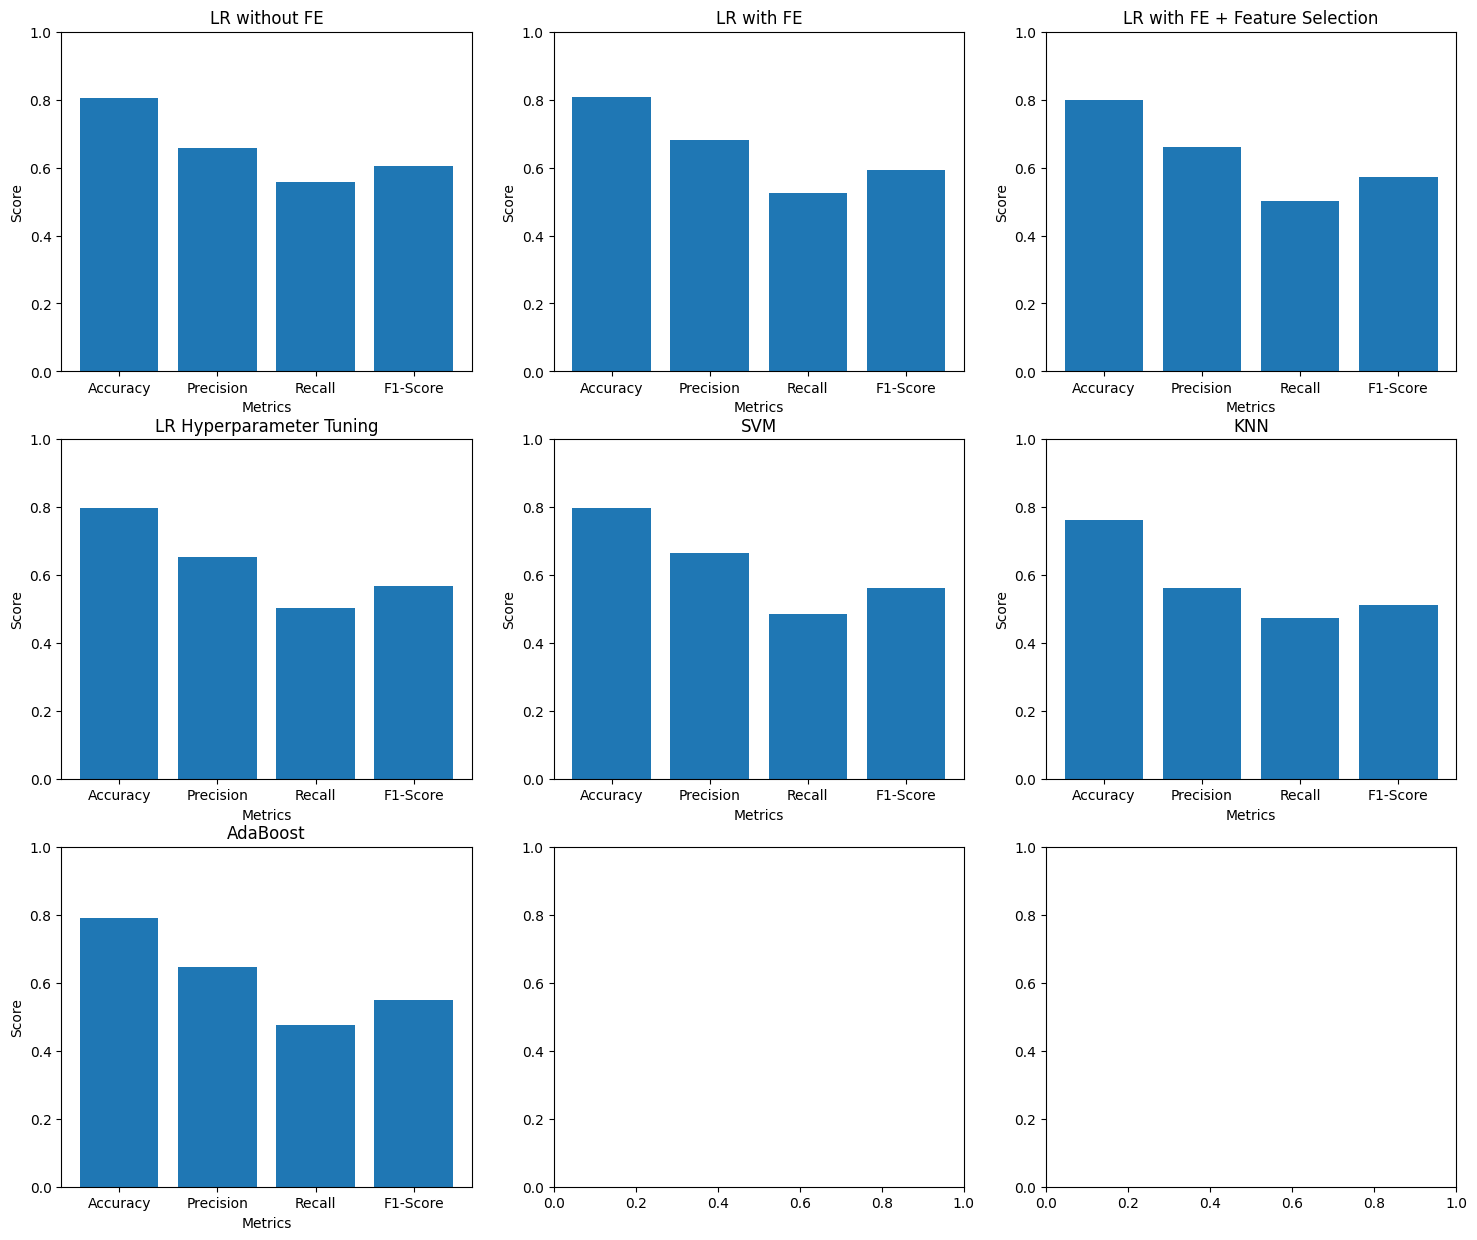

In [1076]:
import matplotlib.pyplot as plt

# model names
models = [
    "LR without FE",
    "LR with FE",
    "LR with FE + Feature Selection",
    "LR Hyperparameter Tuning",
    "SVM",
    "KNN",
    "AdaBoost"
]

# metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# scores

scores_without_feature_eng = [
    classification_report_without_feature_eng['accuracy'],
    classification_report_without_feature_eng['1']['precision'],
    classification_report_without_feature_eng['1']['recall'],
    classification_report_without_feature_eng['1']['f1-score']
]

scores_with_feature_eng = [
    report_with_feature_eng['accuracy'],
    report_with_feature_eng['1']['precision'],
    report_with_feature_eng['1']['recall'],
    report_with_feature_eng['1']['f1-score']
]

scores_with_feature_selection_engineer = [
    report_with_feature_selection_engineer['accuracy'],
    report_with_feature_selection_engineer['1']['precision'],
    report_with_feature_selection_engineer['1']['recall'],
    report_with_feature_selection_engineer['1']['f1-score']
]

scores_tuned_lr = [
    report_tune_lr['accuracy'],
    report_tune_lr['1']['precision'],
    report_tune_lr['1']['recall'],
    report_tune_lr['1']['f1-score']
]

scores_svm = [
    report_svm['accuracy'],
    report_svm['1']['precision'],
    report_svm['1']['recall'],
    report_svm['1']['f1-score']
]

scores_knn = [
    report_knn['accuracy'],
    report_knn['1']['precision'],
    report_knn['1']['recall'],
    report_knn['1']['f1-score']
]

scores_adaboost = [
    report_adaboost['accuracy'],
    report_adaboost['1']['precision'],
    report_adaboost['1']['recall'],
    report_adaboost['1']['f1-score']
]

# combine all scores
all_scores = [
    scores_without_feature_eng,
    scores_with_feature_eng,
    scores_with_feature_selection_engineer,
    scores_tuned_lr,
    scores_svm,
    scores_knn,
    scores_adaboost
]

# create subplot layout
fig, axes = plt.subplots(3, 3, figsize=(18,15))

# flatten axes
axes = axes.flatten()

# plot graphs
for i in range(len(models)):

    axes[i].bar(metrics, all_scores[i])

    axes[i].set_title(models[i])

    axes[i].set_ylim(0,1)

    axes[i].set_xlabel("Metrics")

    axes[i].set_ylabel("Score")








plt.show()